In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from popt.backtest.modules.backtestdata import DataBuilder, DataLoader
from popt.backtest.modules.strategies import (
    MetaStrategy, FixedWeights, Markowitz, asset_plot,
    InverseVolatility,
)
from popt.backtest.modules.simulator import BacktestSimulator, wealth_plot
from popt.backtest.modules.riskmodel import RiskModel

from popt.config import sect, bond, universe

In [12]:
riskmodel = RiskModel.load_from_npz("../../../data/riskmodel/k10_lb6m_hc6m_hv2m.npz")
rd = pd.read_parquet("../../../data/return/return_d.parquet")
rf = pd.read_parquet("../../../data/return/ffr_d.parquet")
alpha_sect = pd.read_parquet("../../../data/alpha/sect.parquet")
alpha_bond = pd.read_parquet("../../../data/alpha/bond.parquet")
print(rd.shape, rf.shape, alpha_bond.shape, alpha_sect.shape)



(8344, 56) (26230, 1) (8344, 87) (8344, 87)


In [13]:
alpha = rd.copy()
alpha[:] = 1.0
# alpha[sect] = alpha_sect[sect]
# alpha[bond] = alpha_bond[bond]

In [ ]:
FIRST_DATE = "2005-01-03"
FINAL_DATE = "2024-12-31"
SPREAD = 5e-4
LEVERAGE = 0.0
VC_LIMIT = 0.08
REBAL_FREQ = "M"

sim = BacktestSimulator(SPREAD)

db = DataBuilder(
    universe=rd.columns,
    first_date=FIRST_DATE,
    final_date=FINAL_DATE,
    alpha=alpha,
    rd=rd,
    rf=rf,
    riskmodel=riskmodel,
    rebal_freq=REBAL_FREQ,
)
# print(db)

Backtest Runtime: 47 ms
Ann Sharpe: 0.6728
Ann Ret:    0.083
Ann Vol:    0.0969
Max DD :    0.2604
Tot Ret:    3.912


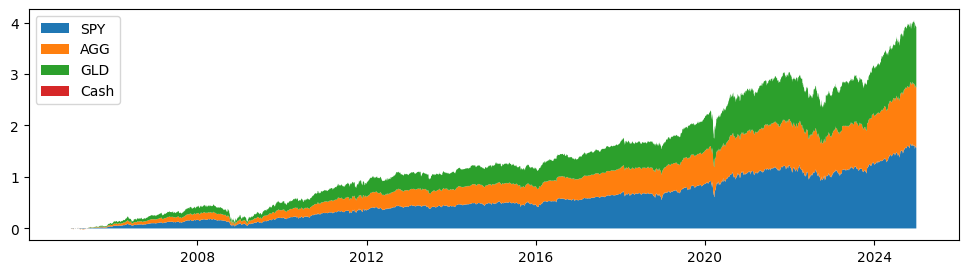

In [34]:
# Why is this sharpe different from the raw sharpe
dl = DataLoader(db=db, tickers=["SPY", "AGG", "GLD"])
one = FixedWeights(
    dl=dl,
    w_rebal=np.array([0.4, 0.3, 0.3]),
    lev=0.0,
    vc_lim=None,
)
sim.run(strategy=one, verbose=True)
wealth_plot(sim)

# existed = dl.timeline[dl._asset_mask.ravel()]
# (1.0+rd[etf].loc[existed][1:]).prod() - 1

Backtest Runtime: 45 ms
Ann Sharpe: 0.6974
Ann Ret:    0.0596
Ann Vol:    0.0606
Max DD :    0.1667
Tot Ret:    2.1783


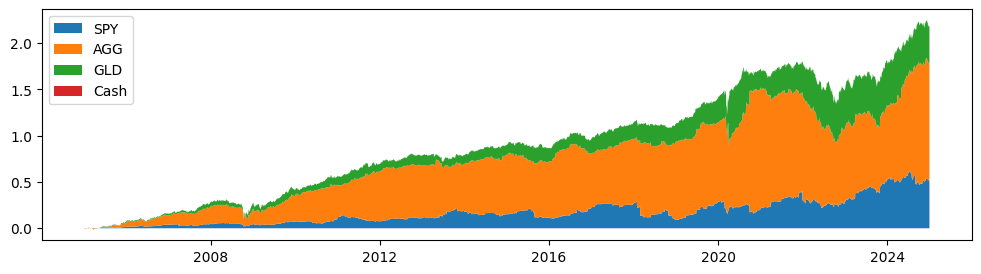

In [35]:
dl = DataLoader(db=db, tickers=["SPY", "AGG", "GLD"])
iv = InverseVolatility(dl)
sim.run(iv, verbose=True)
wealth_plot(sim)

Backtest Runtime: 1464 ms
Ann Sharpe: 0.7264
Ann Ret:    0.0783
Ann Vol:    0.0835
Max DD :    0.1902
Tot Ret:    3.5061


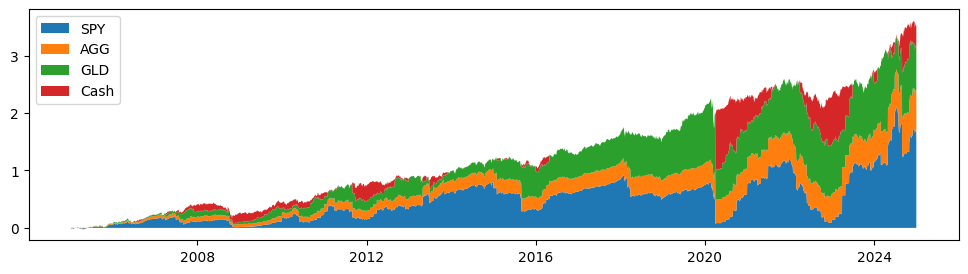

In [43]:
dl = DataLoader(db=db, tickers=["SPY", "AGG", "GLD"])
m_spy = Markowitz(
    dl=dl,
    lookahead=0,
    gamma=SPREAD,
    lev=LEVERAGE,
    w_max=np.array([0.7, 0.2, 0.7]),
    vc_lim=VC_LIMIT,
)
sim.run(strategy=m_spy, verbose=True)
wealth_plot(sim)

In [17]:
# dl = DataLoader(db=db, tickers=["SPY", "AGG", "GLD"])
# one = FixedWeights(
#     dl=dl,
#     w_rebal=np.ones(3)/3,
#     lev=LEVERAGE,
#     vc_lim=VC_LIMIT,
# )
# sim.run(strategy=one, verbose=True)
# wealth_plot(sim)

In [18]:
# dl = DataLoader(db=db, tickers=sect)
# m_sect = Markowitz(
#     dl=dl,
#     lookahead=0,
#     gamma=SPREAD,
#     lev=LEVERAGE,
#     w_max=1.0*np.ones(dl.N),
#     vc_lim=VC_LIMIT,
# )
# sim.run(strategy=m_sect, verbose=True)
# wealth_plot(sim)

In [19]:
# dl = DataLoader(db=db, tickers=bond)
# m_bond = Markowitz(
#     dl=dl,
#     lookahead=0,
#     gamma=SPREAD,
#     lev=LEVERAGE,
#     w_max=0.7*np.ones(dl.N),
#     vc_lim=VC_LIMIT,
# )
# sim.run(strategy=m_bond, verbose=True)
# wealth_plot(sim)

In [20]:
# dl = DataLoader(db=db, tickers=["TLK"])
# m_sect = Markowitz(
#     dl=dl,
#     lookahead=0,
#     gamma=SPREAD,
#     lev=LEVERAGE,
#     w_max=0.7*np.ones(dl.N),
#     vc_lim=VC_LIMIT,
# )
# sim.run(strategy=m_sect, verbose=True)
# wealth_plot(sim)

In [21]:
# dl = DataLoader(db=db, tickers=["SPY"])
# m_spy = Markowitz(
#     dl=dl,
#     lookahead=0,
#     gamma=SPREAD,
#     lev=LEVERAGE,
#     w_max=np.array([1.0]),
#     vc_lim=VC_LIMIT,
# )
# sim.run(strategy=m_spy, verbose=True)
# wealth_plot(sim)

In [22]:
# sbg = ["SPY", "GLD"]
# dl = DataLoader(db=db, tickers=sbg)

# # equal_weights = np.ones(dl.N)/dl.N
# fw = FixedWeights(
#     dl=dl,
#     w_rebal=np.array([0.5, 0.5]),
#     lev=LEVERAGE,
#     vc_lim=VC_LIMIT,
# )
# sim.run(strategy=fw, verbose=True)
# wealth_plot(sim)

# dl = DataLoader(db=db, tickers=sbg)
# m_sbg = Markowitz(
#     dl=dl,
#     lookahead=0,
#     gamma=SPREAD,
#     lev=LEVERAGE,
#     w_max=np.array([0.7, 0.7]),
#     vc_lim=VC_LIMIT,
# )
# sim.run(strategy=m_sbg, verbose=True)
# wealth_plot(sim)

# gld = ["GLD"]
# dl = DataLoader(db=db, tickers=gld)
# m_gld = Markowitz(
#     dl=dl,
#     lookahead=0,
#     gamma=SPREAD,
#     lev=LEVERAGE,
#     w_max=np.array([1.0]),
#     vc_lim=VC_LIMIT,
# )
# sim.run(strategy=m_gld, verbose=True)
# wealth_plot(sim)

# ms = MetaStrategy(
#     db=db,
#     strategies=[m_sect, m_gld, m_bond],
#     w_blend=np.array([0.4, 0.2, 0.4]),
# )
# sim.run(strategy=ms, verbose=True)
# wealth_plot(sim, figsize=(12,4))

In [23]:
# dl = DataLoader(
#     db, ["SPY", "AGG", "GLD", "QQQ", "TLT"]
# )
# FIR = FIRST_DATE
# D09 = "2009-01-01"
# D20 = "2020-01-01"
# D22 = "2022-01-01"
# FIN = FINAL_DATE
# asset_plot(dl, d0=FIR, d1=FIN, figsize=(12, 4))